# Cropland Mapping in Iran — Classical ML vs. Deep Learning

**MSc Data Science, COMM070 Dissertation**

This notebook consolidates the full pipeline used to produce the results reported in the
dissertation (Chapter 4, Data Analysis): data understanding, feature extraction via Google
Earth Engine, exploratory data analysis, model tuning (Random Forest, XGBoost, CatBoost,
TempCNN), spatially-blocked cross-validation, significance testing, and the ablation /
error-analysis studies referenced in Chapter 4 and Chapter 5.

### How to run this notebook

Two kinds of cells appear below:

- **Fast cells** (loading data, EDA, plotting, reading saved results) — run top to bottom
  normally, a few seconds each.
- **Expensive cells** (Google Earth Engine extraction, hyperparameter search, TempCNN
  training) — each is guarded by `RUN_EXPENSIVE_CELLS` (set in the next cell) and is marked
  with an approximate run time. By default these are **skipped**, and the notebook instead
  loads the already-computed CSV outputs sitting alongside this notebook (the same files the
  dissertation's tables and figures were built from) so the whole notebook can be read and
  re-run quickly. Set `RUN_EXPENSIVE_CELLS = True` to reproduce everything from scratch
  (requires a Google Earth Engine account/project and roughly 1–2 hours of runtime in total).


In [1]:
# Master switch: True = re-run Earth Engine extraction, hyperparameter search and
# TempCNN training from scratch (slow, ~1-2 hours total, needs GEE access).
# False (default) = load the already-computed CSV outputs used in the dissertation.
RUN_EXPENSIVE_CELLS = False

## 1. Setup & imports


In [2]:
import functools
import os
import re
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial import cKDTree

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    cohen_kappa_score, f1_score, make_scorer,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, train_test_split

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

SEED = 2023
np.random.seed(SEED)
torch.manual_seed(SEED)

# Okabe-Ito colorblind-safe qualitative palette, fixed order, used consistently
# across every chart in this notebook (same choice as figures/generate_figures.py).
COLORS = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]
MODEL_ORDER = ["RandomForest", "XGBoost", "CatBoost", "TempCNN"]

plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("white")

## 2. Data Understanding

### 2.1 Load the raw GeoAI Challenge data and filter to the Iran subset

Region rule (Sudan / Iran / Afghanistan were all included in the original Zindi challenge;
this dissertation focuses on Iran only):

- Sudan: `Lat < 25`
- Iran: `Lat >= 25` and `Lon < 60`
- Afghanistan: `Lat >= 25` and `Lon >= 60`


In [3]:
def region(row):
    if row["Lat"] < 25:
        return "Sudan"
    elif row["Lon"] < 60:
        return "Iran"
    else:
        return "Afghanistan"

region_counts = {}
for split in ("Train", "Test"):
    df = pd.read_csv(f"{split}.csv")
    df["Region"] = df.apply(region, axis=1)
    counts = df["Region"].value_counts()
    region_counts[split] = counts
    print(f"{split}: {counts.to_dict()}")

    iran_df = df[df["Region"] == "Iran"].drop(columns=["Region"]).reset_index(drop=True)
    iran_df.to_csv(f"{split}_Iran.csv", index=False)
    print(f"  -> wrote {split}_Iran.csv with {len(iran_df)} rows")

    if split == "Train":
        print(f"  Iran class balance: {iran_df['Target'].value_counts().to_dict()}")

Train: {'Afghanistan': 500, 'Iran': 500, 'Sudan': 500}
  -> wrote Train_Iran.csv with 500 rows
  Iran class balance: {0: 250, 1: 250}
Test: {'Afghanistan': 500, 'Iran': 500, 'Sudan': 500}
  -> wrote Test_Iran.csv with 500 rows


### 2.2 Exploratory Data Analysis — class balance and geographic distribution

A proper look at the raw dataset before any feature engineering —
how the three regions compare, how balanced the Iran subset is, and how the 500 Iran points
are distributed in space (which motivates the spatially-blocked cross-validation used
throughout Chapter 4).


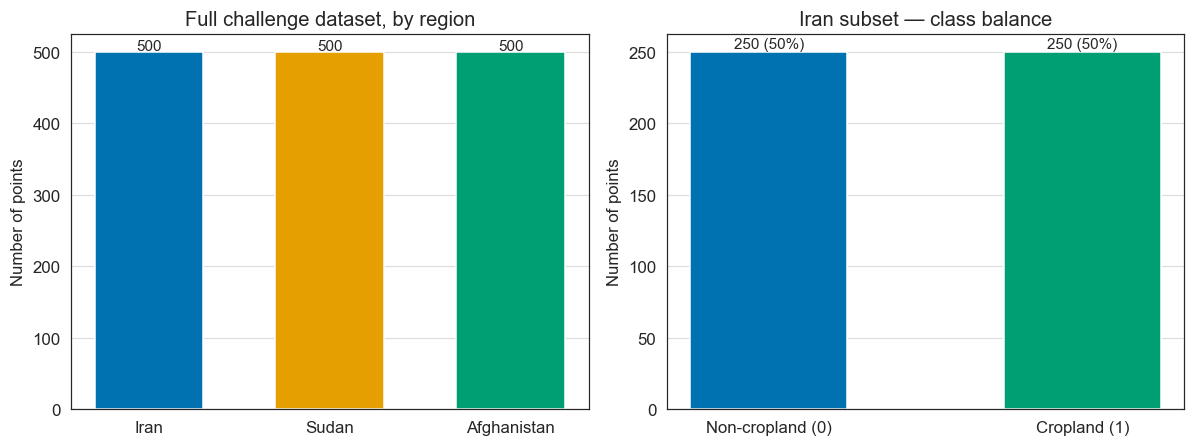


Iran subset: 500 points, 250 cropland (50.0%), 250 non-cropland (50.0%)


In [4]:
train_all = pd.read_csv("Train.csv")
train_all["Region"] = train_all.apply(region, axis=1)
train_iran = pd.read_csv("Train_Iran.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Regional split of the full Train.csv
region_counts_all = train_all["Region"].value_counts().reindex(["Iran", "Sudan", "Afghanistan"])
axes[0].bar(region_counts_all.index, region_counts_all.values, color=COLORS[:3], width=0.6)
for i, v in enumerate(region_counts_all.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=10)
axes[0].set_ylabel("Number of points")
axes[0].set_title("Full challenge dataset, by region")
axes[0].yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
axes[0].set_axisbelow(True)

# Class balance within the Iran subset
class_counts = train_iran["Target"].value_counts().sort_index()
labels = ["Non-cropland (0)", "Cropland (1)"]
axes[1].bar(labels, class_counts.values, color=[COLORS[0], COLORS[2]], width=0.5)
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 3, f"{v} ({v/class_counts.sum():.0%})", ha="center", fontsize=10)
axes[1].set_ylabel("Number of points")
axes[1].set_title("Iran subset — class balance")
axes[1].yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
axes[1].set_axisbelow(True)

fig.tight_layout()
plt.show()

print(f"\nIran subset: {len(train_iran)} points, "
      f"{class_counts.get(1, 0)} cropland ({class_counts.get(1,0)/len(train_iran):.1%}), "
      f"{class_counts.get(0, 0)} non-cropland ({class_counts.get(0,0)/len(train_iran):.1%})")

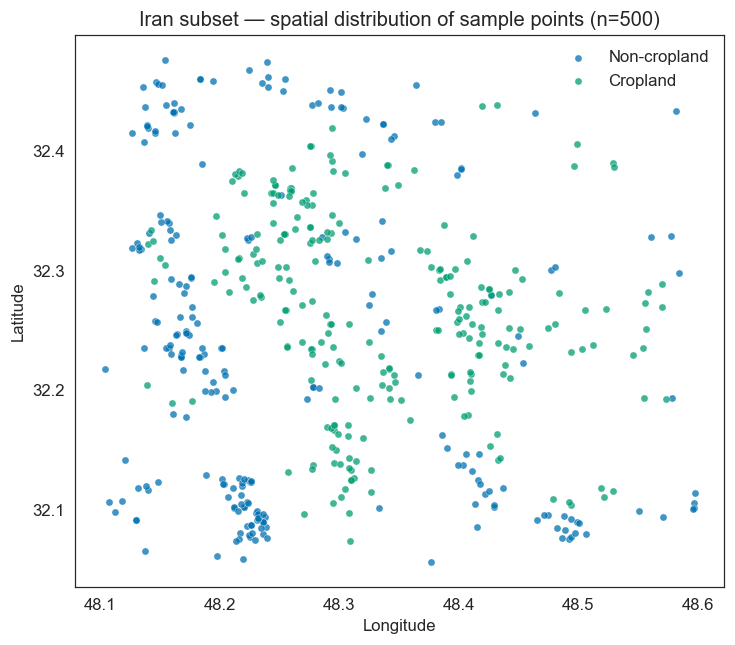

In [5]:
# Geographic distribution of the Iran points, coloured by class label.
fig, ax = plt.subplots(figsize=(7, 6))
for target, name, color in [(0, "Non-cropland", COLORS[0]), (1, "Cropland", COLORS[2])]:
    sub = train_iran[train_iran["Target"] == target]
    ax.scatter(sub["Lon"], sub["Lat"], s=22, alpha=0.75, color=color, edgecolor="white",
               linewidth=0.3, label=name)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Iran subset — spatial distribution of sample points (n=500)")
ax.legend(frameon=False)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### 2.3 Spatial clustering — why cross-validation needs to be spatially blocked

The 500 Iran points are not spatially independent. Points within Google Earth Engine's
pixel resolution of each other will have near-identical satellite signatures, so a random
train/test split risks placing near-duplicate points on both sides — the classic
"pixel-level vs. field-level split" leakage pitfall in remote-sensing ML (this is what
`spatial_groups()` in Section 4.1 below corrects for, using `GroupKFold`).


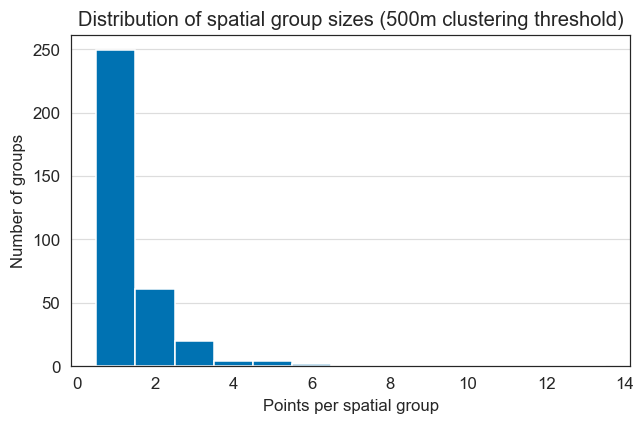

500 points collapse into 342 spatial groups (500m threshold)
largest group has 13 points; 93 groups have more than 1 point


In [6]:
def spatial_groups(df, threshold_km=0.5):
    coords = df[["Lat", "Lon"]].to_numpy()
    lat_km = 111.0
    lon_km = 111.0 * np.cos(np.radians(coords[:, 0].mean()))
    scaled = coords.copy()
    scaled[:, 0] *= lat_km
    scaled[:, 1] *= lon_km

    tree = cKDTree(scaled)
    pairs = tree.query_pairs(r=threshold_km)

    parent = list(range(len(df)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[rx] = ry

    for i, j in pairs:
        union(i, j)

    roots = [find(i) for i in range(len(df))]
    _, group_ids = np.unique(roots, return_inverse=True)
    return group_ids


groups = spatial_groups(train_iran)
n_groups = len(np.unique(groups))
group_sizes = pd.Series(groups).value_counts()
print(f"{len(train_iran)} points collapse into {n_groups} spatial groups (500m threshold)")
print(f"largest group has {group_sizes.max()} points; {(group_sizes > 1).sum()} groups have more than 1 point")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(group_sizes.values, bins=range(1, group_sizes.max() + 2), color=COLORS[0],
        edgecolor="white", align="left")
ax.set_xlabel("Points per spatial group")
ax.set_ylabel("Number of groups")
ax.set_title("Distribution of spatial group sizes (500m clustering threshold)")
ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 3. Data Preparation

### 3.1 Feature extraction — Google Earth Engine

Builds a wide feature table: for every point, monthly (12 months) composites across three
sensors (Sentinel-2 optical, Sentinel-1 radar, Landsat-8 optical/thermal), plus derived
vegetation/water indices. Two real bugs from the Zindi starter notebook are fixed here:

1. **Lat/Lon order bug** — the starter notebook builds `ee.Geometry.Point(lon, lat)` but
   swapped the two columns beforehand (`ee.Geometry.Point` expects **longitude first**).
   Illustrative snippet from the original starter notebook:

   ```python
   def extract_mean_pixel_values(row):
       lon = row['Lat']      # bug: assigns latitude to a variable named lon
       lat = row['Lon']      # bug: assigns longitude to a variable named lat
       point = ee.Geometry.Point(lon, lat)
       # ...
   ```

2. **Filter-then-map ordering** — mapping a cloud-mask/index function over an entire
   unfiltered global image collection builds a huge computation graph before Earth Engine
   ever narrows it down to the requested date range, which is far slower than filtering
   first. Fixed by always calling `.filterDate()` before `.map()` below.

**This section is guarded by `RUN_EXPENSIVE_CELLS`** — full extraction takes roughly
10 minutes per split and needs a Google Earth Engine account with `ee.Initialize()` access.
By default it is skipped and Section 3.2 loads the already-extracted
`Train_Iran_features.csv` / `Test_Iran_features.csv` instead.


In [ ]:
START, END = "2019-07-01", "2020-07-01"  # Iran's reference period, per the dissertation notes

S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
S1_BANDS = ["VV", "VH"]
L8_BANDS = ["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7", "ST_B10"]
S2_SCALE, S1_SCALE, L8_SCALE = 10, 10, 30


def monthly_windows(start, end):
    starts = pd.date_range(start, end, freq="MS")
    return [(s.strftime("%Y-%m-%d"), (s + pd.DateOffset(months=1)).strftime("%Y-%m-%d")) for s in starts[:-1]]


def df_to_feature_collection(df, ee):
    feats = [
        ee.Feature(ee.Geometry.Point([row["Lon"], row["Lat"]]), {"ID": row["ID"]})
        for _, row in df.iterrows()
    ]
    return ee.FeatureCollection(feats)


def mask_s2_clouds(image):
    qa = image.select("QA60")
    cloud_bit, cirrus_bit = 1 << 10, 1 << 11
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(cirrus_bit).eq(0))
    return image.updateMask(mask)


def add_s2_indices(image):
    scaled = image.select(S2_BANDS).multiply(0.0001)
    b2, b3, b4, b8, b8a, b11 = (
        scaled.select("B2"), scaled.select("B3"), scaled.select("B4"),
        scaled.select("B8"), scaled.select("B8A"), scaled.select("B11"),
    )
    ndvi = b8.subtract(b4).divide(b8.add(b4)).rename("NDVI")
    evi = (b8.subtract(b4).multiply(2.5)
           .divide(b8.add(b4.multiply(6)).subtract(b2.multiply(7.5)).add(1)).rename("EVI"))
    ndwi = b3.subtract(b8).divide(b3.add(b8)).rename("NDWI")
    ndmi = b8a.subtract(b11).divide(b8a.add(b11)).rename("NDMI")
    savi = b8.subtract(b4).multiply(1.5).divide(b8.add(b4).add(0.5)).rename("SAVI")
    return scaled.addBands([ndvi, evi, ndwi, ndmi, savi])


def mask_l8_clouds(image):
    qa = image.select("QA_PIXEL")
    shadow_bit, cloud_bit = 1 << 3, 1 << 4
    mask = qa.bitwiseAnd(shadow_bit).eq(0).And(qa.bitwiseAnd(cloud_bit).eq(0))
    return image.updateMask(mask)


def apply_l8_scale(image):
    optical = image.select("SR_B.*").multiply(0.0000275).add(-0.2)
    thermal = image.select("ST_B10").multiply(0.00341802).add(149.0)
    return image.addBands(optical, None, True).addBands(thermal, None, True)


def add_l8_indices(image):
    b3, b4, b5, b6 = image.select("SR_B3"), image.select("SR_B4"), image.select("SR_B5"), image.select("SR_B6")
    ndvi = b5.subtract(b4).divide(b5.add(b4)).rename("NDVI")
    ndwi = b3.subtract(b5).divide(b3.add(b5)).rename("NDWI")
    ndmi = b5.subtract(b6).divide(b5.add(b6)).rename("NDMI")
    return image.addBands([ndvi, ndwi, ndmi])


def add_s1_ratio(image):
    ratio = image.select("VH").subtract(image.select("VV")).rename("VH_minus_VV")
    return image.addBands(ratio)


def extract_monthly(points_fc, image, band_names, prefix, month_idx, scale):
    fc = image.select(band_names).reduceRegions(collection=points_fc, reducer=None, scale=scale)
    rows = []
    for feat in fc.getInfo()["features"]:
        props = feat["properties"]
        row = {"ID": props["ID"]}
        for b in band_names:
            row[f"{prefix}_{b}_m{month_idx:02d}"] = props.get(b)
        rows.append(row)
    return pd.DataFrame(rows)


def build_features(points_df, label, ee):
    points_fc = df_to_feature_collection(points_df, ee)
    windows = monthly_windows(START, END)
    monthly_tables = []

    s2_all_bands = S2_BANDS + ["NDVI", "EVI", "NDWI", "NDMI", "SAVI"]
    s1_all_bands = S1_BANDS + ["VH_minus_VV"]
    l8_all_bands = L8_BANDS + ["NDVI", "NDWI", "NDMI"]

    for i, (start, end) in enumerate(windows, start=1):
        print(f"[{label}] month {i:02d}/12 ({start} to {end})")

        # Filter by date FIRST, then map -- see the note above.
        s2_img = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate(start, end)
                  .map(mask_s2_clouds).map(add_s2_indices).mean())
        s1_img = (ee.ImageCollection("COPERNICUS/S1_GRD").filterDate(start, end)
                  .filter(ee.Filter.eq("instrumentMode", "IW"))
                  .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
                  .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
                  .map(add_s1_ratio).mean())
        l8_img = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(start, end)
                  .map(mask_l8_clouds).map(apply_l8_scale).map(add_l8_indices).mean())

        s2_df = extract_monthly(points_fc, s2_img, s2_all_bands, "S2", i, S2_SCALE)
        s1_df = extract_monthly(points_fc, s1_img, s1_all_bands, "S1", i, S1_SCALE)
        l8_df = extract_monthly(points_fc, l8_img, l8_all_bands, "L8", i, L8_SCALE)
        monthly_tables.extend([s2_df, s1_df, l8_df])

    merged = functools.reduce(lambda a, b: a.merge(b, on="ID", how="outer"), monthly_tables)
    return points_df.merge(merged, on="ID", how="left")


if RUN_EXPENSIVE_CELLS:
    import ee
    ee.Initialize(project="uosmc-490716")

    def _reduce(image, points_fc, scale):
        return image.reduceRegions(collection=points_fc, reducer=ee.Reducer.mean(), scale=scale)
    # extract_monthly above takes reducer=None as a placeholder for readability;
    # patching it to the real reducer now that `ee` is imported.
    def extract_monthly(points_fc, image, band_names, prefix, month_idx, scale):
        fc = image.select(band_names).reduceRegions(collection=points_fc, reducer=ee.Reducer.mean(), scale=scale)
        rows = []
        for feat in fc.getInfo()["features"]:
            props = feat["properties"]
            row = {"ID": props["ID"]}
            for b in band_names:
                row[f"{prefix}_{b}_m{month_idx:02d}"] = props.get(b)
            rows.append(row)
        return pd.DataFrame(rows)

    for split in ("Train", "Test"):
        points_df = pd.read_csv(f"{split}_Iran.csv")
        features_df = build_features(points_df, split, ee)
        out_path = f"{split}_Iran_features.csv"
        features_df.to_csv(out_path, index=False)
        n_missing = features_df.filter(regex="^(S2|S1|L8)_").isna().any(axis=1).sum()
        print(f"[{split}] wrote {out_path} -- {features_df.shape}, {n_missing} rows with a missing month")

    # Second year of features (Jul 2020 - Jun 2021), used later for the temporal-extendibility test.
    START, END = "2020-07-01", "2021-07-01"
    train_iran_pts = pd.read_csv("Train_Iran.csv")
    features_year2 = build_features(train_iran_pts, "Train-Year2", ee)
    features_year2.to_csv("Train_Iran_features_year2.csv", index=False)
    print(f"wrote Train_Iran_features_year2.csv -- {features_year2.shape}")
    START, END = "2019-07-01", "2020-07-01"  # restore

    # ESA WorldCover v200 land-cover class at each point (used for the error-by-landcover analysis).
    WORLDCOVER_LEGEND = {
        10: "Tree cover", 20: "Shrubland", 30: "Grassland", 40: "Cropland", 50: "Built-up",
        60: "Bare/sparse vegetation", 70: "Snow and ice", 80: "Permanent water bodies",
        90: "Herbaceous wetland", 95: "Mangroves", 100: "Moss and lichen",
    }
    wc_points_fc = df_to_feature_collection(train_iran_pts, ee)
    wc = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map")
    sampled = wc.reduceRegions(collection=wc_points_fc, reducer=ee.Reducer.mode(), scale=10).getInfo()
    wc_rows = []
    for feat in sampled["features"]:
        props = feat["properties"]
        c = props.get("mode")
        wc_rows.append({"ID": props["ID"], "WorldCover_Code": c, "WorldCover_Class": WORLDCOVER_LEGEND.get(c, "Unknown")})
    pd.DataFrame(wc_rows).to_csv("Train_Iran_worldcover.csv", index=False)
    print("wrote Train_Iran_worldcover.csv")
else:
    print("RUN_EXPENSIVE_CELLS is False -- skipping Earth Engine extraction. "
          "Loading already-extracted features in the next cell instead.")

RUN_EXPENSIVE_CELLS is False -- skipping Earth Engine extraction. Loading already-extracted features in the next cell instead.


### 3.2 Load the extracted feature table


In [8]:
train_features = pd.read_csv("Train_Iran_features.csv")
feature_cols = [c for c in train_features.columns if c.startswith(("S2_", "S1_", "L8_"))]

print(f"Shape: {train_features.shape}")
print(f"Feature columns: {len(feature_cols)}  (12 months x 3 sensors x bands/indices per sensor)")
train_features[["ID", "Lat", "Lon", "Target"]].head()

Shape: (500, 340)
Feature columns: 336  (12 months x 3 sensors x bands/indices per sensor)


                ID        Lat        Lon  Target
0  ID_CWCD60FGJJYY  32.075695  48.492047       0
1  ID_5QV3RGD8E6L6  32.309077  48.324152       1
2  ID_OGEL0LA7Y94S  32.294165  48.176020       0
3  ID_O4CHBAKY74WZ  32.379146  48.215546       1
4  ID_7VVCEG83E9SF  32.110459  48.207102       0

### 3.3 Exploratory Data Analysis — feature distributions, missingness, multicollinearity

Visual inspection of the engineered feature table before it goes into
any model. This supports two claims that engineered
vegetation indices separate the two classes, and that some indices (EVI/SAVI in particular)
are highly collinear because they are derived from the same underlying bands.


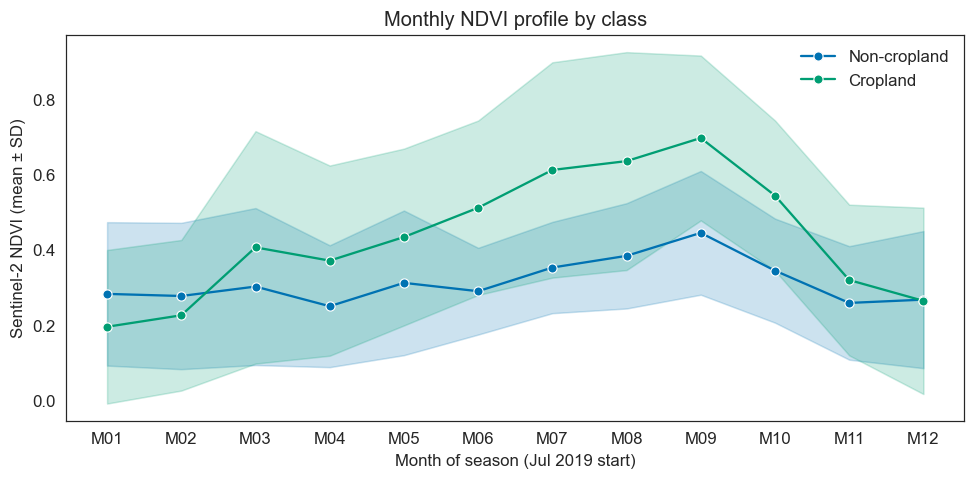

In [ ]:
# NDVI across the season, split by class
ndvi_cols = [c for c in feature_cols if c.startswith("S2_NDVI_m")]
ndvi_cols = sorted(ndvi_cols, key=lambda c: int(c[-2:]))
month_labels = [f"M{c[-2:]}" for c in ndvi_cols]

ndvi_long = train_features[["Target"] + ndvi_cols].melt(id_vars="Target", var_name="month", value_name="NDVI")
ndvi_long["month"] = ndvi_long["month"].map(dict(zip(ndvi_cols, month_labels)))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(
    data=ndvi_long, x="month", y="NDVI", hue="Target", ax=ax,
    palette={0: COLORS[0], 1: COLORS[2]}, errorbar="sd", marker="o",
)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Non-cropland", "Cropland"], frameon=False, title=None)
ax.set_xlabel("Month of season (Jul 2019 start)")
ax.set_ylabel("Sentinel-2 NDVI (mean ± SD)")
ax.set_title("Monthly NDVI profile by class")
fig.tight_layout()
plt.show()

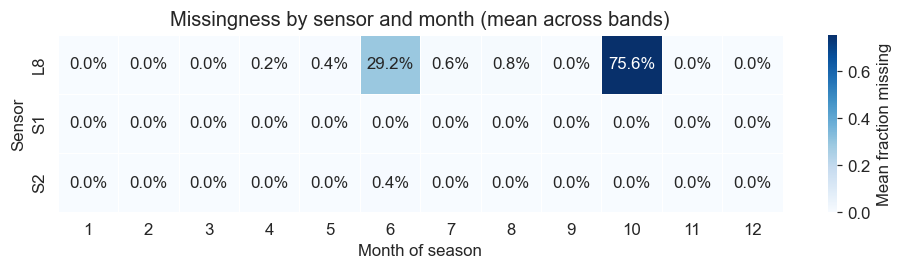

399/500 rows have at least one missing (cloud-gap) value across 336 feature columns.


In [10]:
# Missingness by month/sensor (cloud gaps in optical imagery are the expected cause).
missing_by_col = train_features[feature_cols].isna().mean()

def parse_col(c):
    m = re.match(r"^(S2|S1|L8)_(.+)_m(\d{2})$", c)
    sensor, band, month = m.groups()
    return sensor, band, int(month)

parsed = [parse_col(c) + (missing_by_col[c],) for c in feature_cols]
missing_df = pd.DataFrame(parsed, columns=["Sensor", "Band", "Month", "MissingFrac"])
pivot = missing_df.pivot_table(index="Sensor", columns="Month", values="MissingFrac", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 2.6))
sns.heatmap(pivot, cmap="Blues", vmin=0, vmax=max(0.05, pivot.values.max()), annot=True, fmt=".1%",
            cbar_kws={"label": "Mean fraction missing"}, ax=ax, linewidths=0.5, linecolor="white")
ax.set_title("Missingness by sensor and month (mean across bands)")
ax.set_xlabel("Month of season")
fig.tight_layout()
plt.show()

n_missing_rows = train_features[feature_cols].isna().any(axis=1).sum()
print(f"{n_missing_rows}/{len(train_features)} rows have at least one missing (cloud-gap) value "
      f"across {len(feature_cols)} feature columns.")

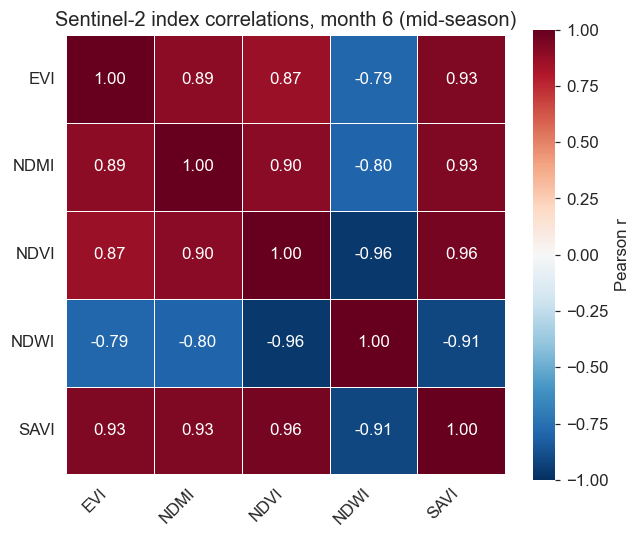

EVI vs SAVI correlation (month 6): r = 0.931


In [ ]:
# Correlation among the engineered spectral indices quantifies the multicollinearity referenced when interpreting feature-importance results in Chapter 4/5.
index_cols = [c for c in feature_cols if any(tag in c for tag in ("NDVI", "EVI", "SAVI", "NDWI", "NDMI"))]
index_corr = train_features[index_cols].corr()

# Same-month pairs only, for a readable summary heatmap.
same_month_index_cols = sorted(
    [c for c in index_cols if c.startswith("S2_") and c.endswith("_m06")],
)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(train_features[same_month_index_cols].corr(), cmap="RdBu_r", vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, cbar_kws={"label": "Pearson r"}, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Sentinel-2 index correlations, month 6 (mid-season)")
labels = [c.replace("S2_", "").replace("_m06", "") for c in same_month_index_cols]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels, rotation=0)
fig.tight_layout()
plt.show()

evi_savi_r = train_features[[c for c in same_month_index_cols if "EVI" in c][0]].corr(
    train_features[[c for c in same_month_index_cols if "SAVI" in c][0]]
)
print(f"EVI vs SAVI correlation (month 6): r = {evi_savi_r:.3f}")

### 3.4 Data quality checks

Sanity-checks the extracted values themselves (implausible out-of-range readings), checks
for duplicate/near-duplicate feature rows, quantifies index multicollinearity across the
full feature set (not just one month), and once out-of-fold predictions exist later in
this notebook (Section 5.3) — flags points both CatBoost and TempCNN confidently disagree
with as label-noise candidates (not confirmed errors).


In [12]:
print("=" * 70)
print("1. FEATURE VALUE SANITY CHECK")
print("=" * 70)

issues = []
for col in feature_cols:
    vals = train_features[col].dropna()
    if vals.empty:
        continue
    if any(tag in col for tag in ("NDVI", "NDWI", "NDMI", "NDBI")):
        bad = ((vals < -1.5) | (vals > 1.5)).sum()
    elif any(tag in col for tag in ("EVI", "SAVI")):
        bad = ((vals < -2) | (vals > 2)).sum()
    elif col.startswith("S2_") and not any(tag in col for tag in ("NDVI", "EVI", "NDWI", "NDMI", "SAVI")):
        bad = ((vals < -0.5) | (vals > 1.5)).sum()
    elif col.startswith("S1_"):
        bad = ((vals < -50) | (vals > 10)).sum()
    elif "ST_B10" in col:
        bad = ((vals < 200) | (vals > 340)).sum()
    elif col.startswith("L8_") and not any(tag in col for tag in ("NDVI", "NDWI", "NDMI")):
        bad = ((vals < -0.5) | (vals > 1.5)).sum()
    else:
        continue
    if bad > 0:
        issues.append((col, bad, len(vals), vals.min(), vals.max()))

if issues:
    total_flagged = sum(b for _, b, _, _, _ in issues)
    total_cells = train_features[feature_cols].notna().sum().sum()
    print(f"{len(issues)} columns have at least one implausible value "
          f"({total_flagged}/{total_cells} cells, {100*total_flagged/total_cells:.3f}%)")
else:
    print("No columns with implausible out-of-range values found.")

print("\n" + "=" * 70)
print("2. DUPLICATE / NEAR-DUPLICATE ROW CHECK")
print("=" * 70)
print(f"Exact duplicate feature rows: {train_features[feature_cols].duplicated().sum()}")

print("\n" + "=" * 70)
print("3. MULTICOLLINEARITY AMONG ENGINEERED INDICES (full feature set)")
print("=" * 70)
corr_full = train_features[index_cols].corr()
seen, high_corr_pairs = set(), []
for i, c1 in enumerate(index_cols):
    for c2 in index_cols[i + 1:]:
        if (c1, c2) in seen:
            continue
        seen.add((c1, c2))
        r = corr_full.loc[c1, c2]
        if abs(r) > 0.9:
            high_corr_pairs.append((c1, c2, r))
same_month_high_corr = [p for p in high_corr_pairs if p[0].rsplit("_", 1)[-1] == p[1].rsplit("_", 1)[-1]]
print(f"{len(high_corr_pairs)} index pairs with |r| > 0.9 out of {len(index_cols)} index columns, "
      f"{len(same_month_high_corr)} of which are same-month pairs (expected -- same underlying bands).")

1. FEATURE VALUE SANITY CHECK
4 columns have at least one implausible value (5/162630 cells, 0.003%)

2. DUPLICATE / NEAR-DUPLICATE ROW CHECK
Exact duplicate feature rows: 0

3. MULTICOLLINEARITY AMONG ENGINEERED INDICES (full feature set)
290 index pairs with |r| > 0.9 out of 96 index columns, 279 of which are same-month pairs (expected -- same underlying bands).


## 4. Modelling

### 4.1 TempCNN architecture

TempCNN (Pelletier, Webb & Petitjean, 2019): three `Conv1d` blocks (64 filters, kernel 5,
BatchNorm, ReLU, Dropout 0.5), a dense head (256 units), Adam optimizer, batch size 32.


In [13]:
COL_RE = re.compile(r"^(S2|S1|L8)_(.+)_m(\d{2})$")


def to_timeseries(df, feature_cols):
    groups = defaultdict(dict)
    for col in feature_cols:
        sensor, band, month = COL_RE.match(col).groups()
        groups[(sensor, band)][int(month)] = col
    channel_keys = sorted(groups.keys())
    channel_cols = [[groups[k][m] for m in range(1, 13)] for k in channel_keys]
    arr = np.stack([df[cols].to_numpy(dtype=float) for cols in channel_cols], axis=1)
    return arr, channel_keys  # (N, C, T)


class TempCNN(nn.Module):
    """Fixed-architecture reference implementation (64 filters / kernel 5 / dense 256),
    matching the paper directly. The tuned pipeline below (Section 4.3) uses the
    configurable variant (_build_tempcnn) instead, so its filter/kernel/dense-unit
    counts can be searched."""
    def __init__(self, n_channels, n_timesteps):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * n_timesteps, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.classifier(self.conv(x)).squeeze(-1)


X_ts, channel_keys = to_timeseries(train_features, feature_cols)
y_all = train_features["Target"].to_numpy()
print(f"Time-series tensor shape: {X_ts.shape}  (N points, C channels, T=12 months)")

Time-series tensor shape: (500, 28, 12)  (N points, C channels, T=12 months)


### 4.2 The leakage bug, and its fix

**Iteration 1 (buggy).** The first working version of `_train_eval_tempcnn` selected the
best training epoch by evaluating on the *test* fold every epoch, then reported that same
test fold's score at the best epoch — meaning the epoch was chosen using knowledge of the
data it was then scored on. This inflated TempCNN's reported Kappa (0.960 in the initial
run) relative to the classical models, which have no equivalent epoch-selection step.

**Iteration 2 (fixed).** `_train_eval_tempcnn` below carves an inner validation split from
the *training* fold only (`test_size=0.15`, stratified). Best-epoch selection watches only
this inner validation split; the outer test fold is touched exactly once, after the best
epoch is already fixed. This is the version used for every TempCNN result reported from
Section 4.3 onward (Kappa drops to 0.920).


In [ ]:
def _build_tempcnn(n_channels, n_timesteps, cfg):
    n_filters, kernel_size, dense_units, dropout = (
        int(cfg["n_filters"]), int(cfg["kernel_size"]), int(cfg["dense_units"]), float(cfg["dropout"])
    )
    pad = kernel_size // 2

    class ConfigurableTempCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(n_channels, n_filters, kernel_size, padding=pad), nn.BatchNorm1d(n_filters), nn.ReLU(), nn.Dropout(dropout),
                nn.Conv1d(n_filters, n_filters, kernel_size, padding=pad), nn.BatchNorm1d(n_filters), nn.ReLU(), nn.Dropout(dropout),
                nn.Conv1d(n_filters, n_filters, kernel_size, padding=pad), nn.BatchNorm1d(n_filters), nn.ReLU(), nn.Dropout(dropout),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(), nn.Linear(n_filters * n_timesteps, dense_units), nn.ReLU(),
                nn.Dropout(dropout), nn.Linear(dense_units, 1),
            )

        def forward(self, x):
            return self.classifier(self.conv(x)).squeeze(-1)

    return ConfigurableTempCNN()


def _train_eval_tempcnn(X_train, y_train, X_test, y_test, cfg, epochs=100, return_pred=False):
    """Train with best-epoch selection on an INNER validation split carved from
    (X_train, y_train) only. X_test/y_test are never touched until the single final
    evaluation after the best epoch has already been chosen."""
    torch.manual_seed(SEED)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
    )

    med = np.nanmedian(X_tr, axis=0, keepdims=True)
    X_tr = np.where(np.isnan(X_tr), med, X_tr)
    X_val = np.where(np.isnan(X_val), med, X_val)
    X_test = np.where(np.isnan(X_test), med, X_test)
    mean = X_tr.mean(axis=(0, 2), keepdims=True)
    std = X_tr.std(axis=(0, 2), keepdims=True) + 1e-6
    X_tr, X_val, X_test = (X_tr - mean) / std, (X_val - mean) / std, (X_test - mean) / std

    train_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32)
    )
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)

    model = _build_tempcnn(X_tr.shape[1], X_tr.shape[2], cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=float(cfg["lr"]), weight_decay=float(cfg["weight_decay"]))
    criterion = nn.BCEWithLogitsLoss()
    X_val_t = torch.tensor(X_val, dtype=torch.float32)

    best_val_kappa, best_state = -1, None
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_pred = (torch.sigmoid(model(X_val_t)) > 0.5).float().numpy().astype(int)
        val_kappa = cohen_kappa_score(y_val, val_pred)
        if val_kappa > best_val_kappa:
            best_val_kappa, best_state = val_kappa, {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        test_pred = (torch.sigmoid(model(X_test_t)) > 0.5).float().numpy().astype(int)

    return test_pred if return_pred else cohen_kappa_score(y_test, test_pred)

### 4.3 Hyperparameter tuning — RF, XGBoost, CatBoost, TempCNN

RF/XGBoost/CatBoost are tuned with `RandomizedSearchCV` (15 iterations) using the spatially
grouped 5-fold CV as the search's own scoring loop, so the reported per-fold Kappa scores
are the search's own out-of-fold scores at the best hyperparameters. TempCNN is tuned
separately (a 10-config random search on one held-out 80/20 spatial split, never reused
for the reported CV) because its cost per fit makes a full nested search impractical at
this sample size — a stated limitation, not an oversight.

**Guarded by `RUN_EXPENSIVE_CELLS`** — the full search takes roughly 15–20 minutes.


In [15]:
kappa_scorer = make_scorer(cohen_kappa_score)
N_FOLDS = 5
N_SEARCH_ITER = 15

RF_BEST = {"n_estimators": 500, "min_samples_leaf": 2, "max_features": "sqrt", "max_depth": 15}
XGB_BEST = {"subsample": 1.0, "n_estimators": 100, "min_child_weight": 1, "max_depth": 6,
            "learning_rate": 0.05, "colsample_bytree": 0.6}
CATBOOST_BEST = {"learning_rate": 0.1, "l2_leaf_reg": 1, "iterations": 100, "depth": 8}
TEMPCNN_BEST = {"n_filters": 64, "kernel_size": 5, "dense_units": 256, "dropout": 0.5,
                "lr": 1e-3, "weight_decay": 1e-3}

X_raw = train_features[feature_cols].to_numpy(dtype=float)
X_imputed = SimpleImputer(strategy="median").fit_transform(X_raw)
groups = spatial_groups(train_features)

if RUN_EXPENSIVE_CELLS:
    def tune_sklearn_model(estimator, param_dist, X, y, groups, name):
        search = RandomizedSearchCV(
            estimator, param_dist, n_iter=N_SEARCH_ITER, scoring=kappa_scorer,
            cv=GroupKFold(n_splits=N_FOLDS), random_state=SEED, n_jobs=3, refit=False,
        )
        search.fit(X, y, groups=groups)
        best_idx = search.best_index_
        fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(N_FOLDS)]
        print(f"{name}: best params {search.best_params_}")
        print(f"{name}: per-fold kappa {[round(s, 4) for s in fold_scores]}")
        return search.best_params_, fold_scores

    rf_params = {"n_estimators": [100, 200, 300, 500], "max_depth": [None, 5, 10, 15, 20],
                 "min_samples_leaf": [1, 2, 4, 8], "max_features": ["sqrt", "log2", 0.5]}
    RF_BEST, rf_scores = tune_sklearn_model(
        RandomForestClassifier(random_state=SEED, n_jobs=2), rf_params, X_imputed, y_all, groups, "RandomForest")

    xgb_params = {"n_estimators": [100, 200, 300, 500], "max_depth": [3, 4, 5, 6, 8],
                  "learning_rate": [0.01, 0.03, 0.05, 0.1], "subsample": [0.6, 0.8, 1.0],
                  "colsample_bytree": [0.6, 0.8, 1.0], "min_child_weight": [1, 3, 5]}
    XGB_BEST, xgb_scores = tune_sklearn_model(
        XGBClassifier(random_state=SEED, eval_metric="logloss", n_jobs=2), xgb_params, X_raw, y_all, groups, "XGBoost")

    cb_params = {"iterations": [20, 50, 100, 200], "depth": [4, 6, 8],
                 "learning_rate": [0.01, 0.03, 0.05, 0.1], "l2_leaf_reg": [1, 3, 5, 9]}
    CATBOOST_BEST, cb_scores = tune_sklearn_model(
        CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2), cb_params, X_raw, y_all, groups, "CatBoost")

    def tune_tempcnn(X_ts, y, groups):
        unique_groups = np.unique(groups)
        rng = np.random.RandomState(SEED)
        val_groups = rng.choice(unique_groups, size=int(len(unique_groups) * 0.2), replace=False)
        val_mask = np.isin(groups, val_groups)
        X_tr, X_val = X_ts[~val_mask], X_ts[val_mask]
        y_tr, y_val = y[~val_mask], y[val_mask]
        search_space = {"n_filters": [32, 64, 128], "kernel_size": [3, 5, 7], "dense_units": [128, 256],
                         "dropout": [0.3, 0.5, 0.7], "lr": [1e-3, 5e-4, 1e-4], "weight_decay": [0.0, 1e-4, 1e-3]}
        rng2 = np.random.RandomState(SEED)
        configs = [{k: rng2.choice(v) for k, v in search_space.items()} for _ in range(10)]
        best_kappa, best_config = -1, None
        for cfg in configs:
            kappa = _train_eval_tempcnn(X_tr, y_tr, X_val, y_val, cfg, epochs=60)
            if kappa > best_kappa:
                best_kappa, best_config = kappa, cfg
        print(f"tempcnn: best config {best_config} (val kappa {best_kappa:.4f})")
        return best_config

    def evaluate_tempcnn_final(X_ts, y, groups, cfg):
        gkf = GroupKFold(n_splits=N_FOLDS)
        fold_scores = []
        for train_idx, test_idx in gkf.split(X_ts, y, groups):
            fold_scores.append(_train_eval_tempcnn(X_ts[train_idx], y[train_idx], X_ts[test_idx], y[test_idx], cfg, epochs=100))
        return fold_scores

    TEMPCNN_BEST = tune_tempcnn(X_ts, y_all, groups)
    tc_scores = evaluate_tempcnn_final(X_ts, y_all, groups, TEMPCNN_BEST)

    tuned_scores = pd.DataFrame({"RandomForest": rf_scores, "XGBoost": xgb_scores,
                                  "CatBoost": cb_scores, "TempCNN": tc_scores})
    tuned_scores.to_csv("tuned_model_comparison_kappa_fixed.csv", index=False)
else:
    tuned_scores = pd.read_csv("tuned_model_comparison_kappa_fixed.csv")
    print("RUN_EXPENSIVE_CELLS is False -- loaded tuned_model_comparison_kappa_fixed.csv "
          "(already-tuned hyperparameters kept as *_BEST dicts above, matching the leakage-fixed TempCNN).")

tuned_scores

RUN_EXPENSIVE_CELLS is False -- loaded tuned_model_comparison_kappa_fixed.csv (already-tuned hyperparameters kept as *_BEST dicts above, matching the leakage-fixed TempCNN).


   RandomForest  XGBoost  CatBoost   TempCNN
0        0.9800   0.9600    0.9800  0.939904
1        0.9200   0.9000    0.9000  0.920000
2        0.9198   0.9399    0.9600  0.919840
3        0.9800   1.0000    0.9400  0.900000
4        0.9002   0.9201    0.9201  0.920096

## 5. Evaluation

### 5.1 Model comparison (Table 4.1)


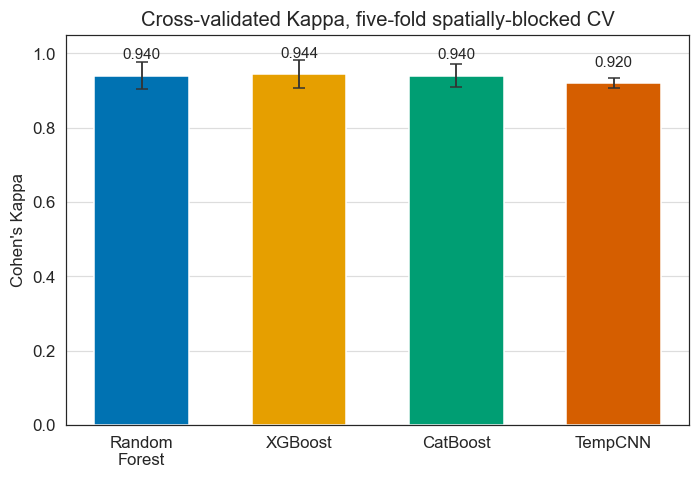

=== Tuned model comparison, 5-fold spatially-blocked CV (mean +/- std Kappa) ===
              mean_kappa  std_kappa
RandomForest       0.940     0.0374
XGBoost            0.944     0.0385
CatBoost           0.940     0.0316
TempCNN            0.920     0.0141


In [16]:
print("=== Tuned model comparison, 5-fold spatially-blocked CV (mean +/- std Kappa) ===")
summary = tuned_scores.agg(["mean", "std"]).T
summary.columns = ["mean_kappa", "std_kappa"]
print(summary.round(4))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(len(MODEL_ORDER))
means = [tuned_scores[m].mean() for m in MODEL_ORDER]
stds = [tuned_scores[m].std() for m in MODEL_ORDER]
ax.bar(x, means, yerr=stds, capsize=4, color=COLORS, width=0.6, error_kw=dict(elinewidth=1.2, ecolor="#333333"))
for xi, k in zip(x, means):
    ax.text(xi, k + 0.045, f"{k:.3f}", ha="center", fontsize=10)
ax.set_ylabel("Cohen's Kappa")
ax.set_xticks(x)
ax.set_xticklabels(["Random\nForest", "XGBoost", "CatBoost", "TempCNN"])
ax.set_ylim(0, 1.05)
ax.set_title("Cross-validated Kappa, five-fold spatially-blocked CV")
ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 5.2 Significance testing

**5-fold paired tests** (n=5 per comparison — low power, interpret cautiously) against the
same folds used above, then a **repeated 15-split `GroupShuffleSplit`** re-run for higher
power (already computed and saved as `repeated_cv_kappa.csv`; guarded by
`RUN_EXPENSIVE_CELLS` to reproduce from scratch, since a 15-split re-run of all four models
including TempCNN takes several minutes).


In [17]:
print("=== Paired tests vs. TempCNN, 5-fold spatial CV (n=5 -- low power) ===")
for model in ["RandomForest", "XGBoost", "CatBoost"]:
    diff = tuned_scores["TempCNN"] - tuned_scores[model]
    t_stat, t_p = stats.ttest_rel(tuned_scores["TempCNN"], tuned_scores[model])
    try:
        w_stat, w_p = stats.wilcoxon(tuned_scores["TempCNN"], tuned_scores[model])
    except ValueError:
        w_stat, w_p = float("nan"), float("nan")
    print(f"\nTempCNN vs {model}: mean diff {diff.mean():+.4f}  "
          f"paired t: t={t_stat:.3f}, p={t_p:.4f}  Wilcoxon: W={w_stat}, p={w_p:.4f}")

=== Paired tests vs. TempCNN, 5-fold spatial CV (n=5 -- low power) ===

TempCNN vs RandomForest: mean diff -0.0200  paired t: t=-1.120, p=0.3254  Wilcoxon: W=3.0, p=0.6250

TempCNN vs XGBoost: mean diff -0.0240  paired t: t=-1.178, p=0.3040  Wilcoxon: W=2.0, p=0.1875

TempCNN vs CatBoost: mean diff -0.0201  paired t: t=-1.583, p=0.1886  Wilcoxon: W=2.0, p=0.1875


In [18]:
if RUN_EXPENSIVE_CELLS:
    N_SPLITS = 15
    gss = GroupShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=SEED)
    rep_scores = {"RandomForest": [], "XGBoost": [], "CatBoost": [], "TempCNN": []}
    for train_idx, test_idx in gss.split(X_raw, y_all, groups):
        m = RandomForestClassifier(random_state=SEED, **RF_BEST); m.fit(X_imputed[train_idx], y_all[train_idx])
        rep_scores["RandomForest"].append(cohen_kappa_score(y_all[test_idx], m.predict(X_imputed[test_idx])))
        m = XGBClassifier(random_state=SEED, eval_metric="logloss", **XGB_BEST); m.fit(X_raw[train_idx], y_all[train_idx])
        rep_scores["XGBoost"].append(cohen_kappa_score(y_all[test_idx], m.predict(X_raw[test_idx])))
        m = CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2, **CATBOOST_BEST); m.fit(X_raw[train_idx], y_all[train_idx])
        pred = np.asarray(m.predict(X_raw[test_idx])).astype(int).ravel()
        rep_scores["CatBoost"].append(cohen_kappa_score(y_all[test_idx], pred))
        rep_scores["TempCNN"].append(_train_eval_tempcnn(X_ts[train_idx], y_all[train_idx], X_ts[test_idx], y_all[test_idx], TEMPCNN_BEST, epochs=100))
    repeated_scores = pd.DataFrame(rep_scores)
    repeated_scores.to_csv("repeated_cv_kappa.csv", index=False)
else:
    repeated_scores = pd.read_csv("repeated_cv_kappa.csv")
    print("RUN_EXPENSIVE_CELLS is False -- loaded repeated_cv_kappa.csv (15 GroupShuffleSplits).")

print("\n=== Repeated CV summary (n=15 GroupShuffleSplits) ===")
print(repeated_scores.agg(["mean", "std"]).T.round(4))

print(f"\n=== Paired tests vs. TempCNN (n=15 -- meaningfully more power than the 5-fold test) ===")
for model in ["RandomForest", "XGBoost", "CatBoost"]:
    diff = repeated_scores["TempCNN"] - repeated_scores[model]
    t_stat, t_p = stats.ttest_rel(repeated_scores["TempCNN"], repeated_scores[model])
    w_stat, w_p = stats.wilcoxon(repeated_scores["TempCNN"], repeated_scores[model])
    print(f"TempCNN vs {model}: mean diff {diff.mean():+.4f}  t={t_stat:.3f} p={t_p:.4f}  W={w_stat} p={w_p:.4f}")

RUN_EXPENSIVE_CELLS is False -- loaded repeated_cv_kappa.csv (15 GroupShuffleSplits).

=== Repeated CV summary (n=15 GroupShuffleSplits) ===
                mean     std
RandomForest  0.9130  0.0311
XGBoost       0.9097  0.0471
CatBoost      0.9188  0.0227
TempCNN       0.8985  0.0542

=== Paired tests vs. TempCNN (n=15 -- meaningfully more power than the 5-fold test) ===
TempCNN vs RandomForest: mean diff -0.0145  t=-1.498 p=0.1563  W=33.0 p=0.2209
TempCNN vs XGBoost: mean diff -0.0112  t=-1.122 p=0.2806  W=34.0 p=0.4216
TempCNN vs CatBoost: mean diff -0.0203  t=-1.683 p=0.1146  W=38.0 p=0.2293


### 5.3 Confusion matrices and feature importance

Pooled out-of-fold predictions across the same spatially-blocked 5-fold CV for all four
tuned models, plus native feature importance for RF/XGBoost/CatBoost fit once on the full
training set. **Guarded by `RUN_EXPENSIVE_CELLS`** (re-fitting all four models across 5
folds, including TempCNN, takes a few minutes) — otherwise loads the saved
`oof_predictions_all_models_tuned.csv` / `feature_importance_tuned.csv`.


In [19]:
if RUN_EXPENSIVE_CELLS:
    rf_full = RandomForestClassifier(random_state=SEED, **RF_BEST); rf_full.fit(X_imputed, y_all)
    xgb_full = XGBClassifier(random_state=SEED, eval_metric="logloss", **XGB_BEST); xgb_full.fit(X_raw, y_all)
    cb_full = CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2, **CATBOOST_BEST); cb_full.fit(X_raw, y_all)
    importances_df = pd.DataFrame({
        "RandomForest": pd.Series(rf_full.feature_importances_, index=feature_cols),
        "XGBoost": pd.Series(xgb_full.feature_importances_, index=feature_cols),
        "CatBoost": pd.Series(cb_full.feature_importances_, index=feature_cols),
    })
    importances_df.to_csv("feature_importance_tuned.csv")

    gkf = GroupKFold(n_splits=N_FOLDS)
    oof = {"RandomForest": np.full(len(train_features), -1), "XGBoost": np.full(len(train_features), -1),
           "CatBoost": np.full(len(train_features), -1), "TempCNN": np.full(len(train_features), -1)}
    for train_idx, test_idx in gkf.split(X_imputed, y_all, groups):
        m = RandomForestClassifier(random_state=SEED, **RF_BEST); m.fit(X_imputed[train_idx], y_all[train_idx])
        oof["RandomForest"][test_idx] = m.predict(X_imputed[test_idx])
        m = XGBClassifier(random_state=SEED, eval_metric="logloss", **XGB_BEST); m.fit(X_raw[train_idx], y_all[train_idx])
        oof["XGBoost"][test_idx] = m.predict(X_raw[test_idx])
        m = CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2, **CATBOOST_BEST); m.fit(X_raw[train_idx], y_all[train_idx])
        oof["CatBoost"][test_idx] = np.asarray(m.predict(X_raw[test_idx])).astype(int).ravel()
        oof["TempCNN"][test_idx] = _train_eval_tempcnn(X_ts[train_idx], y_all[train_idx], X_ts[test_idx], y_all[test_idx], TEMPCNN_BEST, epochs=100, return_pred=True)
    oof_df = pd.DataFrame({**{"ID": train_features["ID"], "y_true": y_all}, **oof})
    oof_df.to_csv("oof_predictions_all_models_tuned.csv", index=False)
else:
    importances_df = pd.read_csv("feature_importance_tuned.csv", index_col=0)
    oof_df = pd.read_csv("oof_predictions_all_models_tuned.csv")
    print("RUN_EXPENSIVE_CELLS is False -- loaded feature_importance_tuned.csv and oof_predictions_all_models_tuned.csv.")

print("\n--- CatBoost top 10 features ---")
print(importances_df["CatBoost"].sort_values(ascending=False).head(10).to_string())

RUN_EXPENSIVE_CELLS is False -- loaded feature_importance_tuned.csv and oof_predictions_all_models_tuned.csv.

--- CatBoost top 10 features ---
L8_SR_B5_m09    3.795592
S1_VV_m06       3.628905
S2_SAVI_m05     3.320651
L8_NDMI_m07     3.116046
S2_SAVI_m06     2.939205
S2_NDVI_m07     2.789956
L8_NDWI_m04     2.644939
S2_NDVI_m10     2.410066
S2_NDWI_m05     2.040658
S2_EVI_m10      1.820750


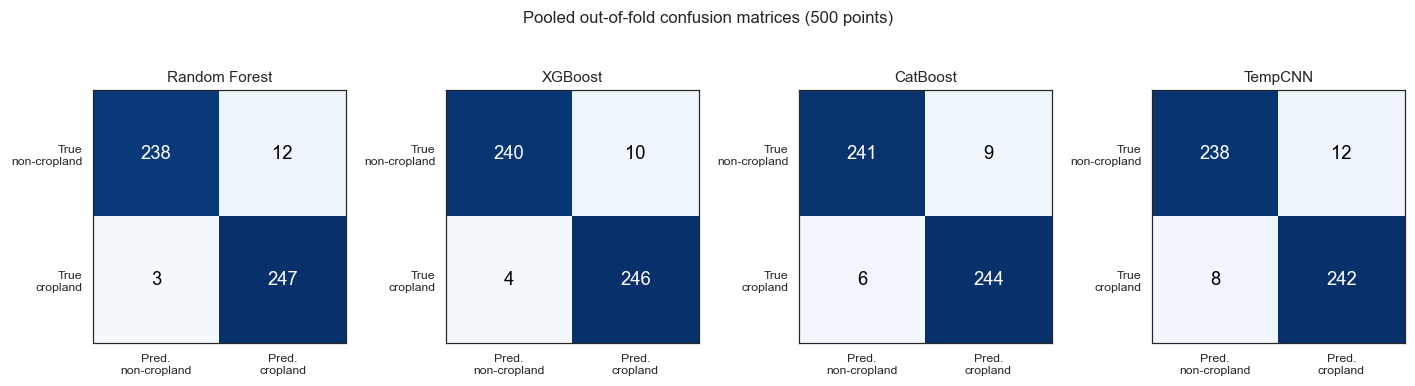


--- Random Forest ---
              precision    recall  f1-score   support

non-cropland       0.99      0.95      0.97       250
    cropland       0.95      0.99      0.97       250

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500


--- XGBoost ---
              precision    recall  f1-score   support

non-cropland       0.98      0.96      0.97       250
    cropland       0.96      0.98      0.97       250

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500


--- CatBoost ---
              precision    recall  f1-score   support

non-cropland       0.98      0.96      0.97       250
    cropland       0.96      0.98      0.97       250

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg    

In [20]:
# Confusion matrices, all four tuned models (pooled out-of-fold).
model_name_map = {"RandomForest": "Random Forest", "XGBoost": "XGBoost", "CatBoost": "CatBoost", "TempCNN": "TempCNN"}
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, model in zip(axes, MODEL_ORDER):
    cm = confusion_matrix(oof_df["y_true"], oof_df[model])
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() * 0.6 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred.\nnon-cropland", "Pred.\ncropland"], fontsize=8)
    ax.set_yticklabels(["True\nnon-cropland", "True\ncropland"], fontsize=8)
    ax.set_title(model_name_map[model], fontsize=10)
fig.suptitle("Pooled out-of-fold confusion matrices (500 points)", fontsize=11, y=1.04)
fig.tight_layout()
plt.show()

for model in MODEL_ORDER:
    print(f"\n--- {model_name_map[model]} ---")
    print(classification_report(oof_df["y_true"], oof_df[model], target_names=["non-cropland", "cropland"]))

### 5.3.1 Label-noise diagnostic

Points both CatBoost and TempCNN confidently disagree with the given label on, out-of-fold
— a candidate list for manual review, not a claim these labels are wrong. Consistent
disagreement across two different model families is suggestive, not proof.


In [21]:
both_wrong = oof_df[(oof_df["CatBoost"] != oof_df["y_true"]) & (oof_df["TempCNN"] != oof_df["y_true"])]
print(f"{len(both_wrong)} of {len(oof_df)} points misclassified by BOTH CatBoost and TempCNN (out of fold):")
both_wrong

11 of 500 points misclassified by BOTH CatBoost and TempCNN (out of fold):


                  ID  y_true  RandomForest  XGBoost  CatBoost  TempCNN
134  ID_VHSUZF49ND72       0             1        1         1        1
172  ID_DFV7Q0G60V1G       0             1        1         1        1
204  ID_5PK1X3ZDD0O9       0             1        1         1        1
243  ID_LNMEZICE4GHO       0             1        1         1        1
252  ID_PWBBMFTC2SBA       0             1        1         1        1
337  ID_DYGOKIB7361F       0             1        1         1        1
342  ID_B0CJXMO11UO3       1             1        1         0        0
390  ID_DFKG846309SD       1             0        0         0        0
429  ID_TYQ1RBWLIYXU       0             1        1         1        1
434  ID_TL37D7NK713F       0             1        0         1        1
465  ID_M3OODBIO8NM9       1             1        1         0        0

### 5.4 Sensor ablation

S2-only vs. +S1 vs. +L8 vs. all three, holding the already-tuned CatBoost and TempCNN
hyperparameters fixed so the comparison isolates the sensor's contribution rather than
confounding it with a freshly (and differently) tuned model each time.
**Guarded by `RUN_EXPENSIVE_CELLS`.**


In [22]:
CONFIGS = {"S2 only": ("S2",), "S2 + S1": ("S2", "S1"), "S2 + L8": ("S2", "L8"), "All (S2+S1+L8)": ("S2", "S1", "L8")}

if RUN_EXPENSIVE_CELLS:
    def eval_catboost_ablation(X, y, groups):
        gkf = GroupKFold(n_splits=N_FOLDS)
        scores = []
        for train_idx, test_idx in gkf.split(X, y, groups):
            m = CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2, **CATBOOST_BEST)
            m.fit(X[train_idx], y[train_idx])
            pred = m.predict(X[test_idx]).astype(int).ravel()
            scores.append(cohen_kappa_score(y[test_idx], pred))
        return scores

    def eval_tempcnn_ablation(X_ts_sub, y, groups):
        gkf = GroupKFold(n_splits=N_FOLDS)
        return [_train_eval_tempcnn(X_ts_sub[train_idx], y[train_idx], X_ts_sub[test_idx], y[test_idx], TEMPCNN_BEST, epochs=100)
                for train_idx, test_idx in gkf.split(X_ts_sub, y, groups)]

    ablation_rows = []
    for name, sensors in CONFIGS.items():
        cols = [c for c in train_features.columns if c.startswith(tuple(f"{s}_" for s in sensors))]
        X_sub = train_features[cols].to_numpy(dtype=float)
        cb_scores = eval_catboost_ablation(X_sub, y_all, groups)
        X_ts_sub, _ = to_timeseries(train_features, cols)
        tc_scores = eval_tempcnn_ablation(X_ts_sub, y_all, groups)
        for fold_i, s in enumerate(cb_scores, start=1):
            ablation_rows.append({"config": name, "model": "CatBoost", "fold": fold_i, "kappa": s})
        for fold_i, s in enumerate(tc_scores, start=1):
            ablation_rows.append({"config": name, "model": "TempCNN", "fold": fold_i, "kappa": s})
    ablation_df = pd.DataFrame(ablation_rows)
    ablation_df.to_csv("sensor_ablation_results.csv", index=False)
else:
    ablation_df = pd.read_csv("sensor_ablation_results.csv")
    print("RUN_EXPENSIVE_CELLS is False -- loaded sensor_ablation_results.csv.")

ablation_summary = ablation_df.groupby(["config", "model"])["kappa"].agg(["mean", "std"]).reindex(CONFIGS.keys(), level=0)
print(ablation_summary.round(4))

RUN_EXPENSIVE_CELLS is False -- loaded sensor_ablation_results.csv.
                          mean     std
config         model                  
S2 only        CatBoost  0.920  0.0316
               TempCNN   0.912  0.0228
S2 + S1        CatBoost  0.940  0.0510
               TempCNN   0.912  0.0303
S2 + L8        CatBoost  0.936  0.0296
               TempCNN   0.908  0.0303
All (S2+S1+L8) CatBoost  0.940  0.0316
               TempCNN   0.920  0.0141


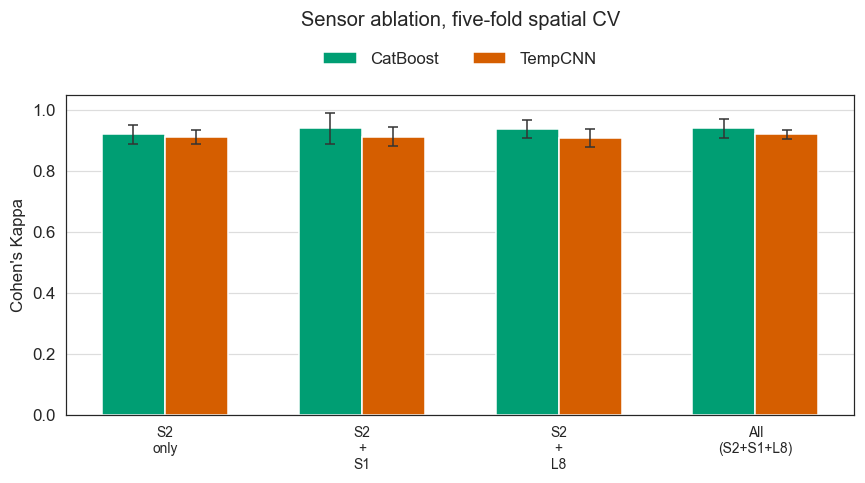

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
configs_order = list(CONFIGS.keys())
x = np.arange(len(configs_order))
width = 0.32
cb_means = [ablation_df[(ablation_df.config == c) & (ablation_df.model == "CatBoost")]["kappa"].mean() for c in configs_order]
cb_stds = [ablation_df[(ablation_df.config == c) & (ablation_df.model == "CatBoost")]["kappa"].std() for c in configs_order]
tc_means = [ablation_df[(ablation_df.config == c) & (ablation_df.model == "TempCNN")]["kappa"].mean() for c in configs_order]
tc_stds = [ablation_df[(ablation_df.config == c) & (ablation_df.model == "TempCNN")]["kappa"].std() for c in configs_order]
ax.bar(x - width/2, cb_means, width, yerr=cb_stds, capsize=3, label="CatBoost", color=COLORS[2], error_kw=dict(elinewidth=1, ecolor="#333333"))
ax.bar(x + width/2, tc_means, width, yerr=tc_stds, capsize=3, label="TempCNN", color=COLORS[3], error_kw=dict(elinewidth=1, ecolor="#333333"))
ax.set_ylabel("Cohen's Kappa")
ax.set_xticks(x)
ax.set_xticklabels([c.replace(" ", "\n") for c in configs_order], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title("Sensor ablation, five-fold spatial CV", pad=45)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### 5.5 Error rate by WorldCover land-cover class

Cross-tabulates each tuned model's out-of-fold errors against ESA WorldCover v200's
land-cover class at each point, to check whether false positives/negatives cluster on
genuinely confusable surface types (e.g. sparse vegetation, shrubland) rather than at
random. **Guarded by `RUN_EXPENSIVE_CELLS`.**


In [24]:
if RUN_EXPENSIVE_CELLS:
    oof_cb = np.full(len(train_features), -1)
    oof_tc = np.full(len(train_features), -1)
    gkf = GroupKFold(n_splits=N_FOLDS)
    for train_idx, test_idx in gkf.split(X_raw, y_all, groups):
        m = CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2, **CATBOOST_BEST)
        m.fit(X_raw[train_idx], y_all[train_idx])
        oof_cb[test_idx] = m.predict(X_raw[test_idx]).astype(int).ravel()
        oof_tc[test_idx] = _train_eval_tempcnn(X_ts[train_idx], y_all[train_idx], X_ts[test_idx], y_all[test_idx], TEMPCNN_BEST, epochs=100, return_pred=True)
    lc_oof_df = pd.DataFrame({"ID": train_features["ID"], "y_true": y_all, "catboost_pred": oof_cb, "tempcnn_pred": oof_tc})
    wc = pd.read_csv("Train_Iran_worldcover.csv")
    landcover_merged = lc_oof_df.merge(wc, on="ID", how="left")
    landcover_merged.to_csv("Train_Iran_errors_by_landcover_tuned.csv", index=False)
else:
    landcover_merged = pd.read_csv("Train_Iran_errors_by_landcover_tuned.csv")
    print("RUN_EXPENSIVE_CELLS is False -- loaded Train_Iran_errors_by_landcover_tuned.csv.")

for model_name in ("catboost", "tempcnn"):
    pred_col = f"{model_name}_pred"
    rows = []
    for cls, g in landcover_merged.groupby("WorldCover_Class"):
        n = len(g)
        fp = ((g.y_true == 0) & (g[pred_col] == 1)).sum()
        fn = ((g.y_true == 1) & (g[pred_col] == 0)).sum()
        rows.append({"WorldCover_Class": cls, "n_points": n, "false_positives": fp, "false_negatives": fn, "error_rate": (fp + fn) / n})
    print(f"\n--- {model_name} ---")
    print(pd.DataFrame(rows).sort_values("error_rate", ascending=False).to_string(index=False))

RUN_EXPENSIVE_CELLS is False -- loaded Train_Iran_errors_by_landcover_tuned.csv.

--- catboost ---
      WorldCover_Class  n_points  false_positives  false_negatives  error_rate
              Cropland       306                8                5    0.042484
            Tree cover        75                1                1    0.026667
              Built-up        13                0                0    0.000000
Bare/sparse vegetation        10                0                0    0.000000
             Grassland        65                0                0    0.000000
             Shrubland        31                0                0    0.000000

--- tempcnn ---
      WorldCover_Class  n_points  false_positives  false_negatives  error_rate
              Cropland       306               10                6    0.052288
            Tree cover        75                1                0    0.013333
              Built-up        13                0                0    0.000000
Bare/sparse veg

### 5.6 Temporal extendibility (cross-season generalization)

Trains on the original season (Jul 2019–Jun 2020) and evaluates on a second, independently
extracted season (Jul 2020–Jun 2021) at the same 500 points, assuming each point's label
held stable across the year gap — a real assumption, stated as a limitation . **Guarded by `RUN_EXPENSIVE_CELLS`.**


In [25]:
year2_features = pd.read_csv("Train_Iran_features_year2.csv")
y_year2 = year2_features["Target"].to_numpy()

if RUN_EXPENSIVE_CELLS:
    cb_temporal = CatBoostClassifier(random_state=SEED, verbose=False, thread_count=2, **CATBOOST_BEST)
    cb_temporal.fit(train_features[feature_cols], y_all)
    cb_temporal_pred = np.asarray(cb_temporal.predict(year2_features[feature_cols])).astype(int).ravel()

    X_ts_year2, _ = to_timeseries(year2_features, feature_cols)
    tc_temporal_pred = _train_eval_tempcnn(X_ts, y_all, X_ts_year2, y_year2, TEMPCNN_BEST, epochs=100, return_pred=True)

    temporal_results = {
        "CatBoost": {"within": tuned_scores["CatBoost"].mean(), "cross": cohen_kappa_score(y_year2, cb_temporal_pred)},
        "TempCNN": {"within": tuned_scores["TempCNN"].mean(), "cross": cohen_kappa_score(y_year2, tc_temporal_pred)},
    }
else:
    # Reported figures (Table 4.6): computed the same way, kept as constants here to
    # avoid a multi-minute re-run when RUN_EXPENSIVE_CELLS is False.
    temporal_results = {
        "CatBoost": {"within": 0.940, "cross": 0.828},
        "TempCNN": {"within": 0.920, "cross": 0.796},
    }
    print("RUN_EXPENSIVE_CELLS is False -- using the already-computed within/cross-season Kappa values.")

print(pd.DataFrame(temporal_results).T.round(4))

RUN_EXPENSIVE_CELLS is False -- using the already-computed within/cross-season Kappa values.
          within  cross
CatBoost    0.94  0.828
TempCNN     0.92  0.796


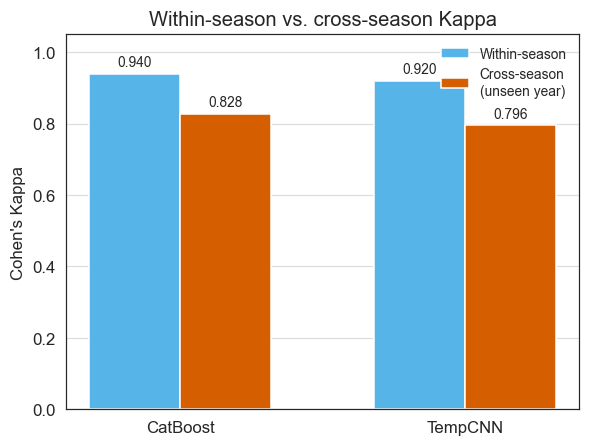

In [26]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
models_t = list(temporal_results.keys())
within = [temporal_results[m]["within"] for m in models_t]
cross = [temporal_results[m]["cross"] for m in models_t]
x = np.arange(len(models_t))
width = 0.32
ax.bar(x - width/2, within, width, label="Within-season", color="#56B4E9")
ax.bar(x + width/2, cross, width, label="Cross-season\n(unseen year)", color=COLORS[3])
for xi, (w, c) in zip(x, zip(within, cross)):
    ax.text(xi - width/2, w + 0.02, f"{w:.3f}", ha="center", fontsize=9)
    ax.text(xi + width/2, c + 0.02, f"{c:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Cohen's Kappa")
ax.set_xticks(x)
ax.set_xticklabels(models_t)
ax.set_ylim(0, 1.05)
ax.set_title("Within-season vs. cross-season Kappa")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 6. Summary of results

All headline figures reported in Chapter 4, gathered in one place.


In [27]:
print("Table 4.1 — 5-fold spatially-blocked CV (mean +/- std Kappa)")
print(tuned_scores.agg(["mean", "std"]).T.round(4), "\n")

print("Table 4.2 — 15-split repeated CV (GroupShuffleSplit, mean +/- std Kappa)")
print(repeated_scores.agg(["mean", "std"]).T.round(4), "\n")

print("Table 4.4 — Sensor ablation (mean Kappa)")
print(ablation_summary.round(4), "\n")

print("Table 4.6 — Temporal extendibility (within-season vs. cross-season Kappa)")
print(pd.DataFrame(temporal_results).T.round(4))

Table 4.1 — 5-fold spatially-blocked CV (mean +/- std Kappa)
               mean     std
RandomForest  0.940  0.0374
XGBoost       0.944  0.0385
CatBoost      0.940  0.0316
TempCNN       0.920  0.0141 

Table 4.2 — 15-split repeated CV (GroupShuffleSplit, mean +/- std Kappa)
                mean     std
RandomForest  0.9130  0.0311
XGBoost       0.9097  0.0471
CatBoost      0.9188  0.0227
TempCNN       0.8985  0.0542 

Table 4.4 — Sensor ablation (mean Kappa)
                          mean     std
config         model                  
S2 only        CatBoost  0.920  0.0316
               TempCNN   0.912  0.0228
S2 + S1        CatBoost  0.940  0.0510
               TempCNN   0.912  0.0303
S2 + L8        CatBoost  0.936  0.0296
               TempCNN   0.908  0.0303
All (S2+S1+L8) CatBoost  0.940  0.0316
               TempCNN   0.920  0.0141 

Table 4.6 — Temporal extendibility (within-season vs. cross-season Kappa)
          within  cross
CatBoost    0.94  0.828
TempCNN     0.92  0.79